In [1]:
!pip install -q pandas numpy matplotlib tensorflow statsmodels scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.arima.model import ARIMA
import warnings
import json
warnings.filterwarnings("ignore")

In [2]:
# Primary: GOV.UK wheat price index (weekly, ~148 weeks)
gov = pd.read_csv("govuk_price_indices_API.csv")
gov_w = gov[gov["category"] == "wheat"].copy()
gov_w["date"] = pd.to_datetime(gov_w["date"])
series = gov_w.groupby("date")["index"].mean().resample("W").mean().dropna()
series.name = "price_index"

# Optional: also load DEFRA £/t for dissertation citation
defra = pd.read_csv("defra_ammg_combined.csv")
wheat_gbp = defra[defra["item"] == "bread_milling_wheat"].copy()
print("GOV.UK wheat weeks:", len(series))
print(series.tail())

series.to_csv("price_weekly.csv")
print("Saved price_weekly.csv for Notebook D")

GOV.UK wheat weeks: 148
date
2025-12-07    102.575500
2026-01-04    101.038029
2026-02-01     99.789609
2026-03-01    102.061608
2026-04-05    105.840362
Name: price_index, dtype: float64
Saved price_weekly.csv for Notebook D


In [3]:
SEQ_LEN = 12   # 12 weeks history
TEST_WEEKS = 20

values = series.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, SEQ_LEN)
split = len(X) - TEST_WEEKS
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print("Train seq:", X_train.shape, "Test seq:", X_test.shape)

Train seq: (116, 12, 1) Test seq: (20, 12, 1)


In [4]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=1, validation_split=0.1)

pred_scaled = model.predict(X_test, verbose=0).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0873 - val_loss: 0.0084
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0269 - val_loss: 0.0352
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0257 - val_loss: 0.0032
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0222 - val_loss: 0.0044
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0166 - val_loss: 0.0064
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0186 - val_loss: 0.0113
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0152 - val_loss: 0.0034
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0216 - val_loss: 0.0036
Epoch 9/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0155 - val_loss: 0.0054
Epoch 10/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0160 - val_loss: 0.0042
Epoch 11/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0157 - val_loss: 0.0043
Epoch 12/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0125 - val_loss: 0.0033
E

In [5]:
train_series = series.iloc[:split + SEQ_LEN]
test_series = series.iloc[split + SEQ_LEN:]

arima = ARIMA(train_series, order=(2, 1, 2))
arima_fit = arima.fit()
arima_pred = arima_fit.forecast(steps=len(test_series))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

lstm_mape = mape(y_true, y_pred)
arima_mape = mape(test_series.values, arima_pred.values)
lstm_rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
lstm_mae = float(mean_absolute_error(y_true, y_pred))

metrics_b = {
    "model": "L3 LSTM price",
    "baseline": "ARIMA(2,1,2)",
    "lstm_mape_pct": round(lstm_mape, 2),
    "arima_mape_pct": round(arima_mape, 2),
    "lstm_rmse": round(lstm_rmse, 4),
    "lstm_mae": round(lstm_mae, 4),
    "lstm_beats_arima": bool(lstm_mape < arima_mape),
    "nfr4_target_pct": 15,
    "nfr4_pass": bool(lstm_mape < 15),
}
print(f"LSTM MAPE:  {metrics_b['lstm_mape_pct']}%")
print(f"ARIMA MAPE: {metrics_b['arima_mape_pct']}%")
print(f"LSTM RMSE:  {metrics_b['lstm_rmse']}")
print(f"LSTM MAE:   {metrics_b['lstm_mae']}")
print(f"LSTM beats ARIMA? {metrics_b['lstm_beats_arima']}")
print(f"NFR4 pass? {'YES' if metrics_b['nfr4_pass'] else 'NO'}")

with open("metrics_b.json", "w") as f:
    json.dump(metrics_b, f, indent=2)

LSTM MAPE:  4.96%
ARIMA MAPE: 9.55%
LSTM RMSE:  5.9589
LSTM MAE:   5.2512
LSTM beats ARIMA? True
NFR4 pass? YES


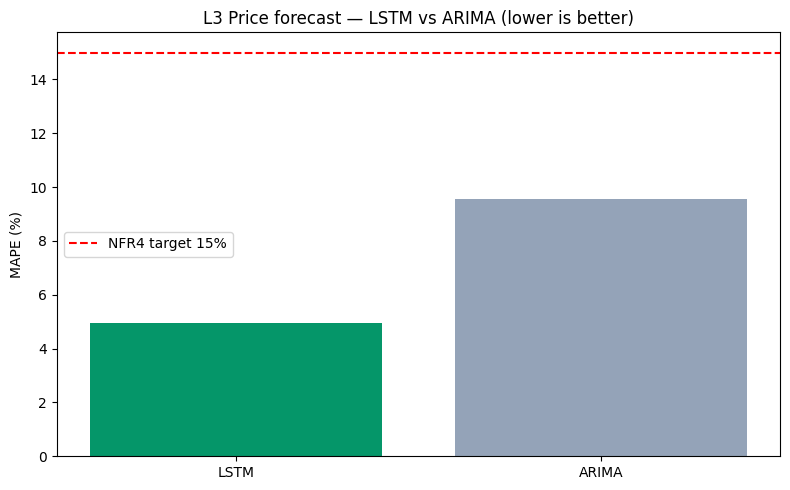

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(["LSTM", "ARIMA"], [metrics_b["lstm_mape_pct"], metrics_b["arima_mape_pct"]], color=["#059669", "#94a3b8"])
plt.ylabel("MAPE (%)")
plt.title("L3 Price forecast — LSTM vs ARIMA (lower is better)")
plt.axhline(15, color="red", linestyle="--", label="NFR4 target 15%")
plt.legend()
plt.tight_layout()
plt.savefig("panel_b_price_mape.png", dpi=150)
plt.show()

model.save("lstm_price.h5")

from google.colab import files
files.download("panel_b_price_mape.png")
files.download("metrics_b.json")
files.download("lstm_price.h5")
files.download("price_weekly.csv")